**Celaning RR intervals and obtaining linear methods**:
This Jupyter notebook focuses on cleaning raw heartbeat data and calculating linear Heart Rate Variability (HRV) metrics. It starts by loading patient electrocardiogram (ECG) data and subject metadata, then filters out physiological artifacts from raw R-peak detections using adaptive statistical and safety rules (such as outlier elimination and interval thresholds). After filtering and comparing the raw vs. refined $RR$ intervals, the code computes a comprehensive suite of linear time-domain, geometric, and frequency-domain HRV metrics (like LF/HF power spectral density via resampling and Welch's periodogram) for each patient, saving the final processed results into a structured dataset and visualizing the final patient demographic distributions.

Using file rr_hr_all_patients.csv containing raw rr intervals

In [2]:
import pandas as pd
import wfdb
import os

# 1. SET YOUR LOCAL PATH
folder_path = r'C:\Users\34673\Desktop\UNI\UNI 2025\TFG\datasest_cardio\dataset_cardio' 

# 2. LOAD THE CSV
csv_path = os.path.join(folder_path, 'subject-info.csv')
subject_info = pd.read_csv(csv_path)

# Convert the ID column to match your filenames (e.g., 1 -> '0001')
subject_info['ID_str'] = subject_info['ID'].astype(str).str.zfill(4)
subject_info.set_index('ID_str', inplace=True)

# 3. LOAD RECORDS AND BIND INFO
patients = {}

for i in range(1, 1122):
    pid = str(i).zfill(4)
    record_path = os.path.join(folder_path, pid)
    
    if os.path.exists(record_path + '.hea'):
        try:
            # Load the signals (ECG1, ECG2, NIBP)
            record = wfdb.rdrecord(record_path)
            
            # Link CSV data to the record object
            if pid in subject_info.index:
                # Store the CSV row as a dictionary inside the record
                record.metadata = subject_info.loc[pid].to_dict()
            else:
                record.metadata = None
                
            patients[pid] = record
            
        except Exception as e:
            print(f"Error loading {pid}: {e}")

print(f"Total patients with signals and metadata: {len(patients)}")

Error loading 0400: [Errno 2] No such file or directory: 'C:/Users/34673/Desktop/UNI/UNI 2025/TFG/datasest_cardio/dataset_cardio/0400.dat'
Total patients with signals and metadata: 1120


**1. RR intervals vectors and HRV preprocessing** 

In [24]:
import pandas as pd
import numpy as np
import ast
from scipy.interpolate import PchipInterpolator
from scipy.signal import welch

# --- 1. Configuration ---
FS = 1000          # Original ECG Sampling frequency (Hz)
FS_RESAMPLE = 4    # Standard HRV Resampling frequency (Hz)
INPUT_FILE = "rr_hr_all_patients.csv"
OUTPUT_FILE = "final_hrv_linear_results.csv"

# --- 2. Processing Functions ---

def refine_rr_intervals(r_peak_indices, fs=1000):
    """Refines RR intervals using physiological rules and absolute safety gates."""
    peaks = np.array(r_peak_indices, dtype=float)
    if len(peaks) < 2: return np.array([]), np.array([])
    
    # i. Initial Physiological Filter (Min 200ms distance)
    refined_peaks = [peaks[0]]
    for i in range(1, len(peaks)):
        if (peaks[i] - refined_peaks[-1]) >= (0.2 * fs):
            refined_peaks.append(peaks[i])
    peaks = np.array(refined_peaks)
    
    # ii. Statistical Outlier Elimination (70%/180% rule)
    idx = 2
    while idx < len(peaks) - 2:
        current_rr = (peaks[idx] - peaks[idx-1]) * (1000 / fs)
        avg_rr = np.mean(np.diff(peaks[idx-2 : idx+3])) * (1000 / fs)

        # Safety Gate: Remove impossible long intervals (> 3s / 20bpm)
        if current_rr > 3000:
            peaks = np.delete(peaks, idx)
            continue 
            
        if current_rr < (0.7 * avg_rr) or current_rr > (1.8 * avg_rr) or current_rr > 2000:
            peaks = np.delete(peaks, idx)
            continue 
        idx += 1
    
    # iii. Final Filtering and Alignment
    final_rr_intervals = np.diff(peaks) * (1000 / fs)
    valid_mask = (final_rr_intervals > 300) & (final_rr_intervals < 3000)
    final_rr_intervals = final_rr_intervals[valid_mask]
    refined_timestamps = peaks[1:][valid_mask] 
    
    return final_rr_intervals, refined_timestamps


In [25]:
import pandas as pd
import numpy as np
import ast
import os

#1. Configuration 
FS = 1000  # ECG Sampling frequency (Hz)
INPUT_FILE = "rr_hr_all_patients.csv"
REFINED_SIGNAL_FILE = "refined_rr_signals.csv"  # File to store preprocessed intervals

#2. Processing and Saving Loop

# Load raw peak data
df = pd.read_csv(INPUT_FILE)
df['R_peak_indices'] = df['R_peak_indices'].apply(ast.literal_eval)

refined_signal_data = []

for _, row in df.iterrows():
    pid = row['Patient_ID']
    
    # Run your physiological refinement 
    # nn_vals = final_rr_intervals (ms), aligned_ts = refined_timestamps (samples)
    nn_vals, aligned_ts = refine_rr_intervals(row['R_peak_indices'], FS)
    
    # Check for minimum length 
    if len(nn_vals) > 50:
        refined_signal_data.append({
            "Patient_ID": pid,
            "final_rr_intervals": nn_vals.tolist(),
            "refined_timestamps": aligned_ts.tolist()
        })

# Save the preprocessed signals for later linear/non-linear metric calculation
refined_df = pd.DataFrame(refined_signal_data)
refined_df.to_csv(REFINED_SIGNAL_FILE, index=False)

print(f"Refined RR intervals saved to {REFINED_SIGNAL_FILE}")

Refined RR intervals saved to refined_rr_signals.csv


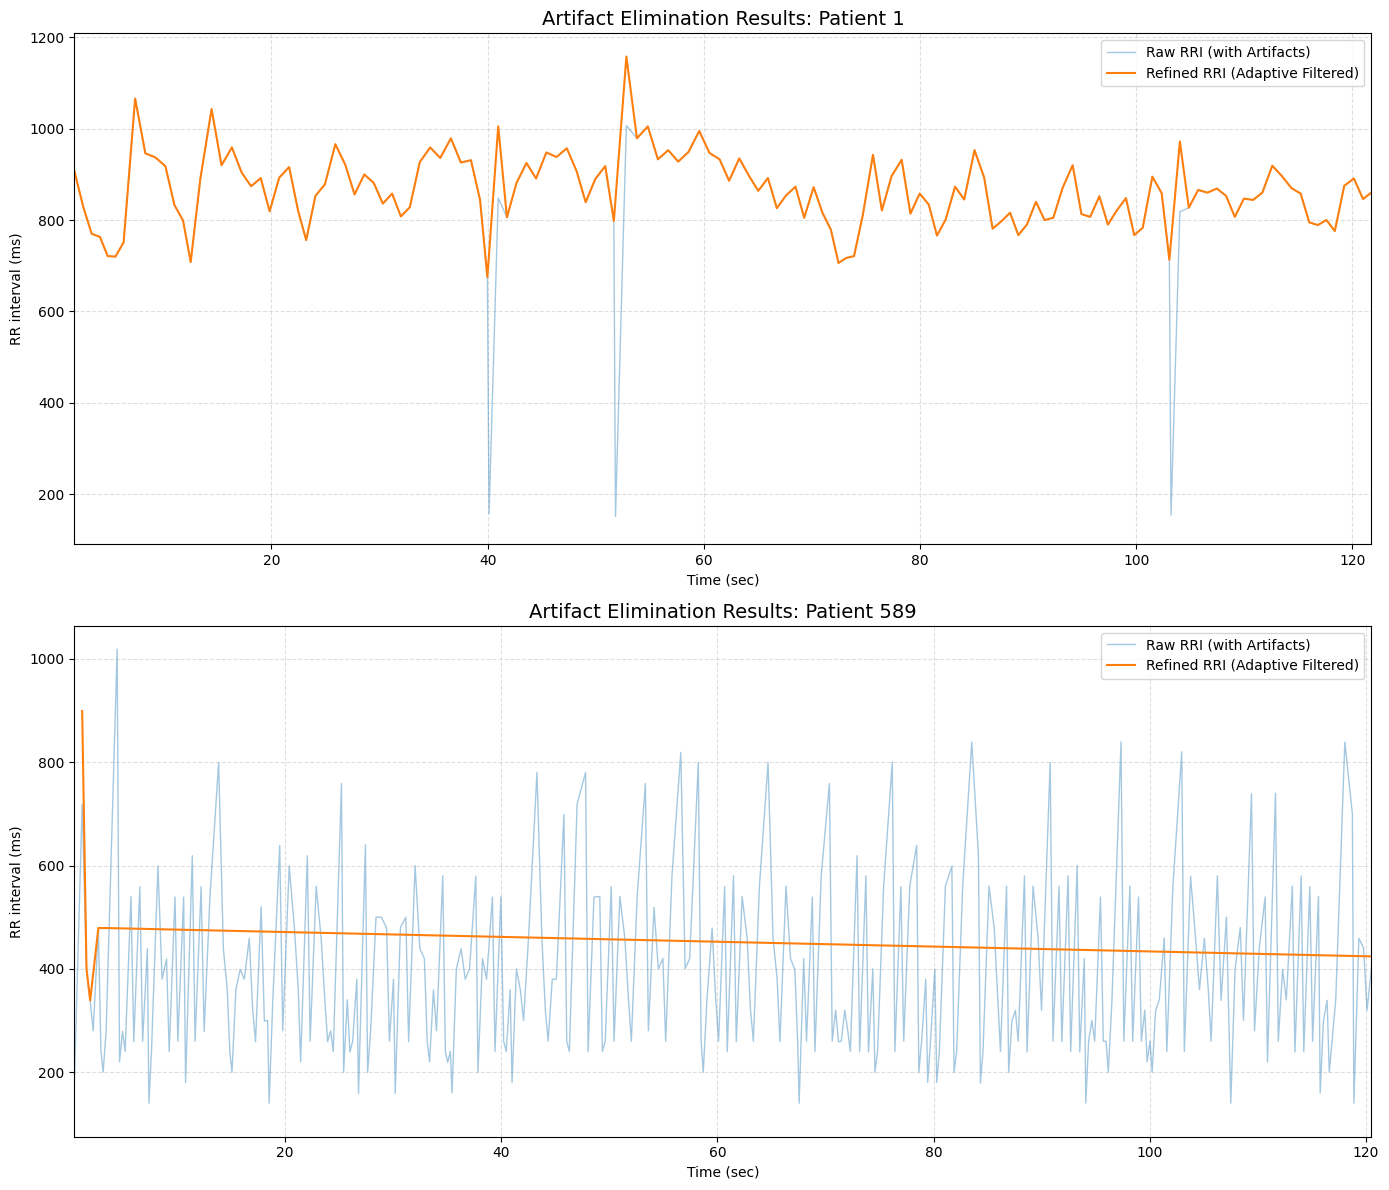

In [26]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

#1. Load and Prepare Data
df = pd.read_csv("rr_hr_all_patients.csv")
# Ensure indices are treated as numerical lists
df['R_peak_indices'] = df['R_peak_indices'].apply(ast.literal_eval)

target_ids = [1, 589]
FS = 1000  # Sampling Frequency

#2. Plotting Loop 
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for i, pid in enumerate(target_ids):
    # Select Patient data
    try:
        row_data = df[df['Patient_ID'] == pid].iloc[0]
    except IndexError:
        print(f"Patient ID {pid} not found in dataset.")
        continue

    # Prepare Raw Series
    raw_indices = np.array(row_data['R_peak_indices'], dtype=float)
    raw_rr = np.diff(raw_indices) * (1000 / FS)
    time_raw = raw_indices[1:] / FS

    # Prepare Refined Series 
    refined_rr, refined_ts = refine_rr_intervals(row_data['R_peak_indices'], FS)
    time_refined = refined_ts / FS

    # Plotting on corresponding subplot
    axes[i].plot(time_raw, raw_rr, label='Raw RRI (with Artifacts)', color='tab:blue', alpha=0.4, linewidth=1)
    axes[i].plot(time_refined, refined_rr, label='Refined RRI (Adaptive Filtered)', color='tab:orange', linewidth=1.5)

    # Styling and Context
    axes[i].set_title(f'Artifact Elimination Results: Patient {pid}', fontsize=14)
    axes[i].set_xlabel('Time (sec)', fontsize=10)
    axes[i].set_ylabel('RR interval (ms)', fontsize=10)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.4)
    
    # Focus window (First 2 minutes) to see beat-to-beat details
    axes[i].set_xlim(time_raw[0], time_raw[0] + 120)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# Load both files
original_df = pd.read_csv("rr_hr_all_patients.csv")
refined_df = pd.read_csv("refined_rr_signals.csv")

# Get unique patient counts
total_patients = original_df['Patient_ID'].nunique()
kept_patients = refined_df['Patient_ID'].nunique()
discarded_patients = total_patients - kept_patients

# Calculate percentage
discard_rate = (discarded_patients / total_patients) * 100

print(f"--- Refinement Summary ---")
print(f"Total patients in original file: {total_patients}")
print(f"Patients kept after refinement:  {kept_patients}")
print(f"Patients discarded:              {discarded_patients} ({discard_rate:.2f}%)")

if discarded_patients > 0:
    discarded_ids = set(original_df['Patient_ID']) - set(refined_df['Patient_ID'])
    print(f"Discarded Patient IDs: {list(discarded_ids)}")

--- Refinement Summary ---
Total patients in original file: 1112
Patients kept after refinement:  1085
Patients discarded:              27 (2.43%)
Discarded Patient IDs: [649, 1038, 665, 284, 414, 159, 423, 554, 300, 48, 186, 1089, 834, 71, 75, 587, 77, 589, 975, 465, 469, 92, 495, 244, 373, 761, 505]


**2. Linear methods**

In [28]:
import pandas as pd
import numpy as np
import ast
from scipy.interpolate import PchipInterpolator
from scipy.signal import welch

#1. Configuration 
FS = 1000          # Original ECG Sampling frequency (Hz)
FS_RESAMPLE = 4    # Standard HRV Resampling frequency (Hz)
INPUT_FILE = "refined_rr_signals.csv"
OUTPUT_FILE = "final_hrv_linear_results.csv"

#2. Processing Functions 

def calculate_time_domain(nn):
    """Calculates Linear Time-Domain and sdaNN1 metrics."""
    diff_nn = np.abs(np.diff(nn))
    mean_nn = np.mean(nn)
    sd_nn = np.std(nn, ddof=1)
    
    rmssd = np.sqrt(np.mean(diff_nn**2))
    pnn50 = (np.sum(diff_nn > 50) / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    pnnI20 = (np.sum(diff_nn < 20) / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    cv_nn = sd_nn / mean_nn if mean_nn > 0 else 0

    one_min_ms = 60000
    cum_time = np.cumsum(nn)
    averages_1min = []
    start = 0
    while start + one_min_ms <= cum_time[-1]:
        mask = (cum_time > start) & (cum_time <= start + one_min_ms)
        if np.any(mask):
            averages_1min.append(np.mean(nn[mask]))
        start += one_min_ms
    sdann1 = np.std(averages_1min, ddof=1) if len(averages_1min) > 1 else 0
    
    return {
        "meanNN_ms": mean_nn, "sdNN_ms": sd_nn, "rmssd_ms": rmssd,
        "sdaNN1_ms": sdann1, "pNN50_pct": pnn50, "cvNN": cv_nn,
        "pNNI20_pct": pnnI20
    }

def calculate_geometric(nn):
    """Calculates Geometric HRV metrics (Poincaré and Histogram-based)."""

    rr_n = nn[:-1]
    rr_n1 = nn[1:]

    
    # 2. HRV Triangular Index
    bin_width = 1 / 128 * 1000  # Standard bin width is ~7.8ms
    bins = np.arange(min(nn), max(nn) + bin_width, bin_width)
    hist, _ = np.histogram(nn, bins=bins)
    tri_index = len(nn) / np.max(hist) if np.max(hist) > 0 else 0

    # 3. TINN (Triangular Interpolation of NN interval histogram)
    tinn = 4 * np.std(nn, ddof=1)

    return {
        "HRV_Tri_Index": tri_index,
        "TINN_ms": tinn
    }

def calculate_spectral(nn, timestamps, fs_orig=1000, fs_new=4):
    """Interpolates using PCHIP and calculates Linear Spectral metrics."""
    time_seconds = timestamps / fs_orig
    time_interp = np.arange(time_seconds[0], time_seconds[-1], 1/fs_new)
    
    pchip = PchipInterpolator(time_seconds, nn)
    rr_interp = pchip(time_interp)
    
    rr_detrended = rr_interp - np.mean(rr_interp)
    freqs, psd = welch(rr_detrended, fs=fs_new, nperseg=min(len(rr_detrended), 256))
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.4)
    
    lf = np.trapezoid(psd[lf_mask], freqs[lf_mask])
    hf = np.trapezoid(psd[hf_mask], freqs[hf_mask])
    p_total = lf + hf
    
    return {
        "LF_ms2": lf, "HF_ms2": hf, "P_ms2": p_total,
        "LF_HF_ratio": lf / hf if hf > 0 else 0,
        "LFn": lf / p_total if p_total > 0 else 0,
        "HFn": hf / p_total if p_total > 0 else 0
    }



# --- Loop ---
df = pd.read_csv(INPUT_FILE)
df['final_rr_intervals'] = df['final_rr_intervals'].apply(ast.literal_eval)
df['refined_timestamps'] = df['refined_timestamps'].apply(ast.literal_eval)

master_results = []
for _, row in df.iterrows():
    nn_vals, ts = np.array(row['final_rr_intervals']), np.array(row['refined_timestamps'])
    if len(nn_vals) > 20:
        res = {"Patient_ID": row['Patient_ID']}
        res.update(calculate_time_domain(nn_vals))
        res.update(calculate_spectral(nn_vals, ts, FS, FS_RESAMPLE))
        res.update(calculate_geometric(nn_vals))
        master_results.append(res)

pd.DataFrame(master_results).to_csv(OUTPUT_FILE, index=False)
print(f"Success! Linear metrics saved to {OUTPUT_FILE}.")
    
  

Success! Linear metrics saved to final_hrv_linear_results.csv.


Cleaned Patients: 1085
Total Males: 414
Total Females: 671

Age Group Distribution:
2.0: 414
7.0: 48
4.0: 97
3.0: 223
1.0: 43
9.0: 18
8.0: 50
Unknown: 25
12.0: 12
5.0: 42
10.0: 24
11.0: 19
6.0: 47
13.0: 7
15.0: 6
14.0: 10


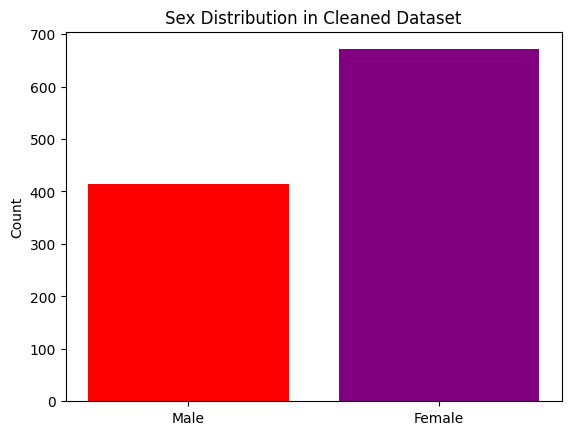

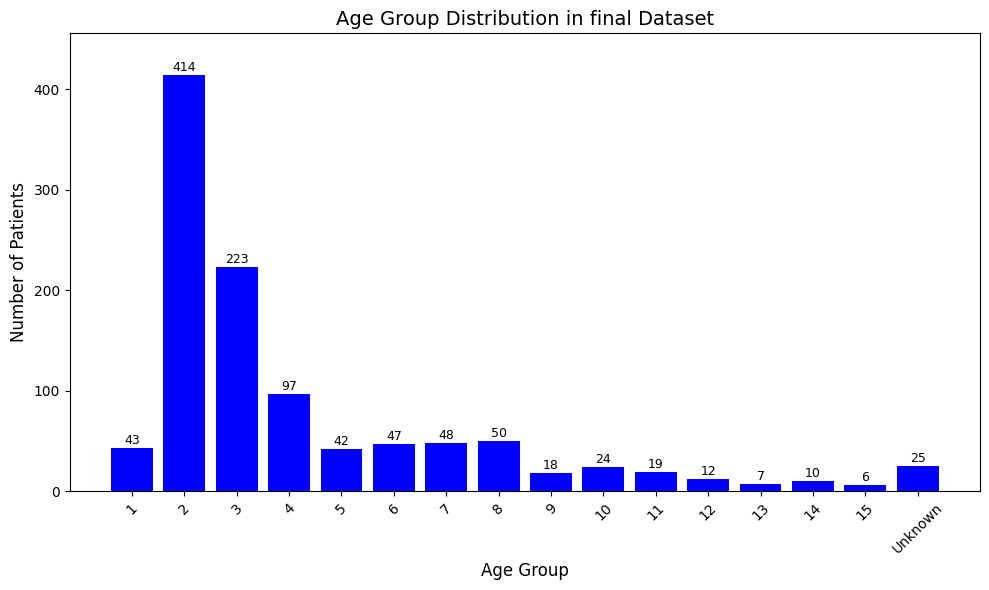

In [29]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# 1️ Load cleaned CSV
df_clean = pd.read_csv(r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG\final_hrv_linear_results.csv")

# 3️ Loop through cleaned patients
male_count = 0
female_count = 0
age_counter = Counter()

for pid in df_clean["Patient_ID"]:
    pid = str(pid).strip().zfill(4) 

    if pid in patients:
        metadata = patients[pid].metadata

        if metadata.get("Sex") == 0.0:
            male_count += 1
        else:
            female_count += 1

        from collections import Counter


    
   
        
        age_group = metadata.get("Age_group", "Unknown") 

        if age_group is None or (isinstance(age_group, float) and np.isnan(age_group)):
            age_group = "Unknown"

        age_counter[age_group] += 1

    else:
        print(f"Warning: Patient {pid} not found in patients dict")


# 4️ Print Results

print("Cleaned Patients:", len(df_clean))
print("Total Males:", male_count)
print("Total Females:", female_count)

print("\nAge Group Distribution:")
for age_group, count in age_counter.items():
    print(f"{age_group}: {count}")

# 5️ Optional: Plot

# Sex distribution
plt.figure()
plt.bar(["Male", "Female"], [male_count, female_count], color=['red', 'purple'])
plt.title("Sex Distribution in Cleaned Dataset")
plt.ylabel("Count")
plt.show()

# Age group distribution
import matplotlib.pyplot as plt


# 1️. Clean and separate keys

numeric_age = []
numeric_counts = []

unknown_count = 0

for k, count in age_counter.items():
    if k == "Unknown" or k is None or (isinstance(k, float) and np.isnan(k)):
        unknown_count += int(count)
    else:
        numeric_age.append(int(float(k)))  # convert to int
        numeric_counts.append(int(count))

# Sort numeric age groups
sorted_pairs = sorted(zip(numeric_age, numeric_counts), key=lambda x: x[0])
sorted_age, sorted_counts = zip(*sorted_pairs) if sorted_pairs else ([], [])

# Add "Unknown" at the end if exists
if unknown_count > 0:
    sorted_age = list(sorted_age) + ["Unknown"]
    sorted_counts = list(sorted_counts) + [unknown_count]

# Convert all x-values to strings for plotting
x_labels = [str(a) for a in sorted_age]


# 2️. Plot

plt.figure(figsize=(10, 6))
bars = plt.bar(x_labels, sorted_counts, color='blue')

# Add counts on top of bars
for bar, count in zip(bars, sorted_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Age Group Distribution in final Dataset", fontsize=14)
plt.ylabel("Number of Patients", fontsize=12)
plt.xlabel("Age Group", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(sorted_counts)*1.1)
plt.tight_layout()
plt.show()